<img src="https://media-exp1.licdn.com/dms/image/C4E1BAQEMI2VQQ5_Utw/company-background_10000/0/1583983402116?e=2159024400&v=beta&t=Yhx0JDUeUOAT-GVzNFn-CsJLu63KdxKQqGBkjGybOsM">

<h1 align="center">Clustering jerárquico</h1>

### ¿En qué consiste?


Agrupamiento jerárquico van generando grupos en cada una de las fases del proceso buscando el número de clúster que hacer una agrupación óptima.

El agrupamiento jerárquico es capaz de fijar por si solos el número de clústers, por ello se pueden utilizar de forma exploratoria y posteriormente aplicar un análisis no jerárquico con el número de clúster ya fijado.

### Categorías
Los algoritmos de agrupamiento jerárquico se dividen en 2 categorías:

* Divisivo o De arriba hacia abajo, estos algoritmos tratan cuando se inicia con todas las observaciones contenidas en un mismo cluster y se suceden divisiones hasta que cada observación forma un cluster* individual.

* La agrupación jerárquica de abajo hacia arriba se denomina agrupación aglomerativa jerárquica o HAC. Esta jerarquía de grupos se representa como un árbol (o dendrograma).El agrupamiento se inicia con todas las observaciones separadas, cada una formando un cluster individual. Los clusters se van combinado a medida que la estructura crece hasta converger en uno solo.

La raíz del árbol es el grupo único que reúne todas las muestras, siendo las hojas los grupos con una sola muestra. La agrupación de los puntos de datos se representa mediante un dendrograma.

<img src="https://miro.medium.com/max/700/1*ET8kCcPpr893vNZFs8j4xg.gif">


### Tipos de vínculos
* Enlace único: Se calcula la distancia entre todos los posibles pares formados por una observación del cluster A y una del cluster B. La menor de todas ellas se selecciona como la distancia entre los dos clusters. Se trata de la medida menos conservadora.
* Enlace completo: se calcula la distancia entre todos los posibles pares formados por una observación del cluster A y una del cluster B. La mayor de todas ellas se selecciona como la distancia entre los dos clusters. Se trata de la medida más conservadora
* Enlace promedio: Se calcula la distancia entre todos los posibles pares formados por una observación del cluster A y una del cluster B. El valor promedio de todas ellas se selecciona como la distancia entre los dos clusters.
* Centroide: Se calcula el centroide de cada uno de los clusters y se selecciona la distancia entre ellos como la distancia entre los dos clusters.
* Ward: Se trata de un método general. El objetivo es minimizar la suma total de varianza intra-cluster.

### ¿Cómo funciona?
* Comenzamos tratando cada punto de datos como un solo grupo, es decir, si hay X puntos de datos en nuestro conjunto de datos, entonces tenemos X grupos. Luego seleccionamos una métrica de distancia, que se encarga de medir la distancia entre dos grupos.

* En cada iteración, combinamos dos grupos en uno. Los dos grupos que se van a combinar se seleccionan como aquellos con el menor vínculo promedio. Es decir, de acuerdo con nuestra métrica de distancia seleccionada, estos dos grupos tienen la distancia más pequeña entre sí y, por lo tanto, son los más similares y deben combinarse.

El paso 2 se repite hasta que llegamos a la raíz del árbol, es decir, solo tenemos un grupo que contiene todos los puntos de datos.

### Características
* No requiere que especifiquemos el número de grupos e incluso podemos seleccionar qué número de grupos se ve mejor ya que estamos construyendo un árbol.
* El algoritmo no es sensible a la elección de la métrica de distancia; todos tienden a funcionar igual de bien, mientras que con otros algoritmos de agrupamiento, la elección de la métrica de distancia es fundamental.
* Estas ventajas de la agrupación jerárquica tienen el costo de una menor eficiencia, ya que tiene una complejidad de tiempo de O (n³), a diferencia de la complejidad lineal de K-Means y GMM.
* Un caso de uso particularmente bueno de los métodos de agrupamiento jerárquico es cuando los datos subyacentes tienen una estructura jerárquica y desea recuperar la jerarquía; otros algoritmos de agrupación en clústeres no pueden hacer esto.

## Metodos de Evaluacion

* Metodo de la Silueta: Es una medida de cuán similar es un objeto a su propio cúmulo (cohesión) en comparación con otros cúmulos (separación). La silueta puede ser calculada con cualquier métrica distancia, como la distancia euclidiana o la distancia Manhattan.

* Dendrograma: Es como un árbol en el que las ramas representan la jerarquía con la que se van sucediendo las uniones de clusters. Cada observación forma una terminación individual conocida como hoja o leaf del árbol. A medida que se asciende por la estructura, pares de hojas se fusionan formando las primeras ramas. Estas uniones se corresponden con los pares de observaciones más similares. También ocurre que las ramas se fusionan con otras ramas o con hojas. Cuanto más temprana (más próxima a la base del dendrograma) ocurre una fusión, mayor es la similitud.


# Ejercicio Práctico


Descripción de los datos:
* manufact: Nombre del fabricante
* model: Nombre del modelo
* sales: Ventas
* resale: Valor de reventa
* type: Tipo, indica 1 si es un camión/camioneta y 0 de lo contrario.
* price: Precio del vehículo.
* engine_s: Tamaño del motor
* horsepow: Caballos de fuerza
* wheelbas: Distancia entre ejes
* width: Ancho
* length: Largo
* curb_wgt: Peso del vehículo
* fuel_cap: Capacidad del tanque
* mpg: Millas por galón

#### Importación de los datos

In [4]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/Curso Estadistica con Python/cars_clus.csv")
df.head()

,manufact,model,sales,resale,type,price,engine_s,horsepow,wheelbas,width,length,curb_wgt,fuel_cap,mpg,lnsales,partition
0,Acura,Integra,16.919,16.360,0.000,21.500,1.800,140.000,101.200,67.300,172.400,2.639,13.200,28.000,2.828,0.0
1,Acura,TL,39.384,19.875,0.000,28.400,3.200,225.000,108.100,70.300,192.900,3.517,17.200,25.000,3.673,0.0
2,Acura,CL,14.114,18.225,0.000,$null$,3.200,225.000,106.900,70.600,192.000,3.470,17.200,26.000,2.647,0.0
3,Acura,RL,8.588,29.725,0.000,42.000,3.500,210.000,114.600,71.400,196.600,3.850,18.000,22.000,2.150,0.0
4,Audi,A4,20.397,22.255,0.000,23.990,1.800,150.000,102.600,68.200,178.000,2.998,16.400,27.000,3.015,0.0


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#### Dimensiones

In [6]:
print ("Shape of dataset: ", df.shape)

df.head(5)

Shape of dataset:  (159, 16)


,manufact,model,sales,resale,type,price,engine_s,horsepow,wheelbas,width,length,curb_wgt,fuel_cap,mpg,lnsales,partition
0,Acura,Integra,16.919,16.360,0.000,21.500,1.800,140.000,101.200,67.300,172.400,2.639,13.200,28.000,2.828,0.0
1,Acura,TL,39.384,19.875,0.000,28.400,3.200,225.000,108.100,70.300,192.900,3.517,17.200,25.000,3.673,0.0
2,Acura,CL,14.114,18.225,0.000,$null$,3.200,225.000,106.900,70.600,192.000,3.470,17.200,26.000,2.647,0.0
3,Acura,RL,8.588,29.725,0.000,42.000,3.500,210.000,114.600,71.400,196.600,3.850,18.000,22.000,2.150,0.0
4,Audi,A4,20.397,22.255,0.000,23.990,1.800,150.000,102.600,68.200,178.000,2.998,16.400,27.000,3.015,0.0


#### Tipos de datos

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   manufact   157 non-null    object 
 1   model      159 non-null    object 
 2   sales      159 non-null    object 
 3   resale     159 non-null    object 
 4   type       159 non-null    object 
 5   price      159 non-null    object 
 6   engine_s   159 non-null    object 
 7   horsepow   159 non-null    object 
 8   wheelbas   159 non-null    object 
 9   width      159 non-null    object 
 10  length     159 non-null    object 
 11  curb_wgt   159 non-null    object 
 12  fuel_cap   159 non-null    object 
 13  mpg        159 non-null    object 
 14  lnsales    159 non-null    object 
 15  partition  159 non-null    float64
dtypes: float64(1), object(15)
memory usage: 20.0+ KB


#### Revisión de valores faltantes

In [8]:
df.isna().sum()

,0
manufact,2
model,0
sales,0
resale,0
type,0
price,0
engine_s,0
horsepow,0
wheelbas,0
width,0


#### Limpieza de valores nulos

In [9]:
df.dropna().shape

(157, 16)

In [10]:
df[df.price=='$null$']

,manufact,model,sales,resale,type,price,engine_s,horsepow,wheelbas,width,length,curb_wgt,fuel_cap,mpg,lnsales,partition
2,Acura,CL,14.114,18.225,0.000,$null$,3.200,225.000,106.900,70.600,192.000,3.470,17.200,26.000,2.647,0.0
33,Chrysler,Town & Country,53.480,19.540,1.000,$null$,$null$,$null$,$null$,$null$,$null$,$null$,$null$,$null$,3.979,0.0


In [11]:
import numpy as np
df=df.replace('null', np.nan, regex=True)
df.head(7)

,manufact,model,sales,resale,type,price,engine_s,horsepow,wheelbas,width,length,curb_wgt,fuel_cap,mpg,lnsales,partition
0,Acura,Integra,16.919,16.360,0.000,21.500,1.800,140.000,101.200,67.300,172.400,2.639,13.200,28.000,2.828,0.0
1,Acura,TL,39.384,19.875,0.000,28.400,3.200,225.000,108.100,70.300,192.900,3.517,17.200,25.000,3.673,0.0
2,Acura,CL,14.114,18.225,0.000,NaN,3.200,225.000,106.900,70.600,192.000,3.470,17.200,26.000,2.647,0.0
3,Acura,RL,8.588,29.725,0.000,42.000,3.500,210.000,114.600,71.400,196.600,3.850,18.000,22.000,2.150,0.0
4,Audi,A4,20.397,22.255,0.000,23.990,1.800,150.000,102.600,68.200,178.000,2.998,16.400,27.000,3.015,0.0
5,Audi,A6,18.780,23.555,0.000,33.950,2.800,200.000,108.700,76.100,192.000,3.561,18.500,22.000,2.933,0.0
6,Audi,A8,1.380,39.000,0.000,62.000,4.200,310.000,113.000,74.000,198.200,3.902,23.700,21.000,0.322,0.0


In [12]:
df.isna().sum()

,0
manufact,2
model,0
sales,2
resale,38
type,2
price,2
engine_s,1
horsepow,1
wheelbas,1
width,1


In [13]:
df=df.dropna()

In [14]:
df.head(15)

,manufact,model,sales,resale,type,price,engine_s,horsepow,wheelbas,width,length,curb_wgt,fuel_cap,mpg,lnsales,partition
0,Acura,Integra,16.919,16.360,0.000,21.500,1.800,140.000,101.200,67.300,172.400,2.639,13.200,28.000,2.828,0.0
1,Acura,TL,39.384,19.875,0.000,28.400,3.200,225.000,108.100,70.300,192.900,3.517,17.200,25.000,3.673,0.0
3,Acura,RL,8.588,29.725,0.000,42.000,3.500,210.000,114.600,71.400,196.600,3.850,18.000,22.000,2.150,0.0
4,Audi,A4,20.397,22.255,0.000,23.990,1.800,150.000,102.600,68.200,178.000,2.998,16.400,27.000,3.015,0.0
5,Audi,A6,18.780,23.555,0.000,33.950,2.800,200.000,108.700,76.100,192.000,3.561,18.500,22.000,2.933,0.0
6,Audi,A8,1.380,39.000,0.000,62.000,4.200,310.000,113.000,74.000,198.200,3.902,23.700,21.000,0.322,0.0
8,BMW,328i,9.231,28.675,0.000,33.400,2.800,193.000,107.300,68.500,176.000,3.197,16.600,24.000,2.223,0.0
9,BMW,528i,17.527,36.125,0.000,38.900,2.800,193.000,111.400,70.900,188.000,3.472,18.500,24.800,2.864,0.0
10,Buick,Century,91.561,12.475,0.000,21.975,3.100,175.000,109.000,72.700,194.600,3.368,17.500,25.000,4.517,0.0
11,Buick,Regal,39.350,13.740,0.000,25.300,3.800,240.000,109.000,72.700,196.200,3.543,17.500,23.000,3.672,0.0


#### Exploración de variables continuas

<Axes: xlabel='sales', ylabel='Density'>

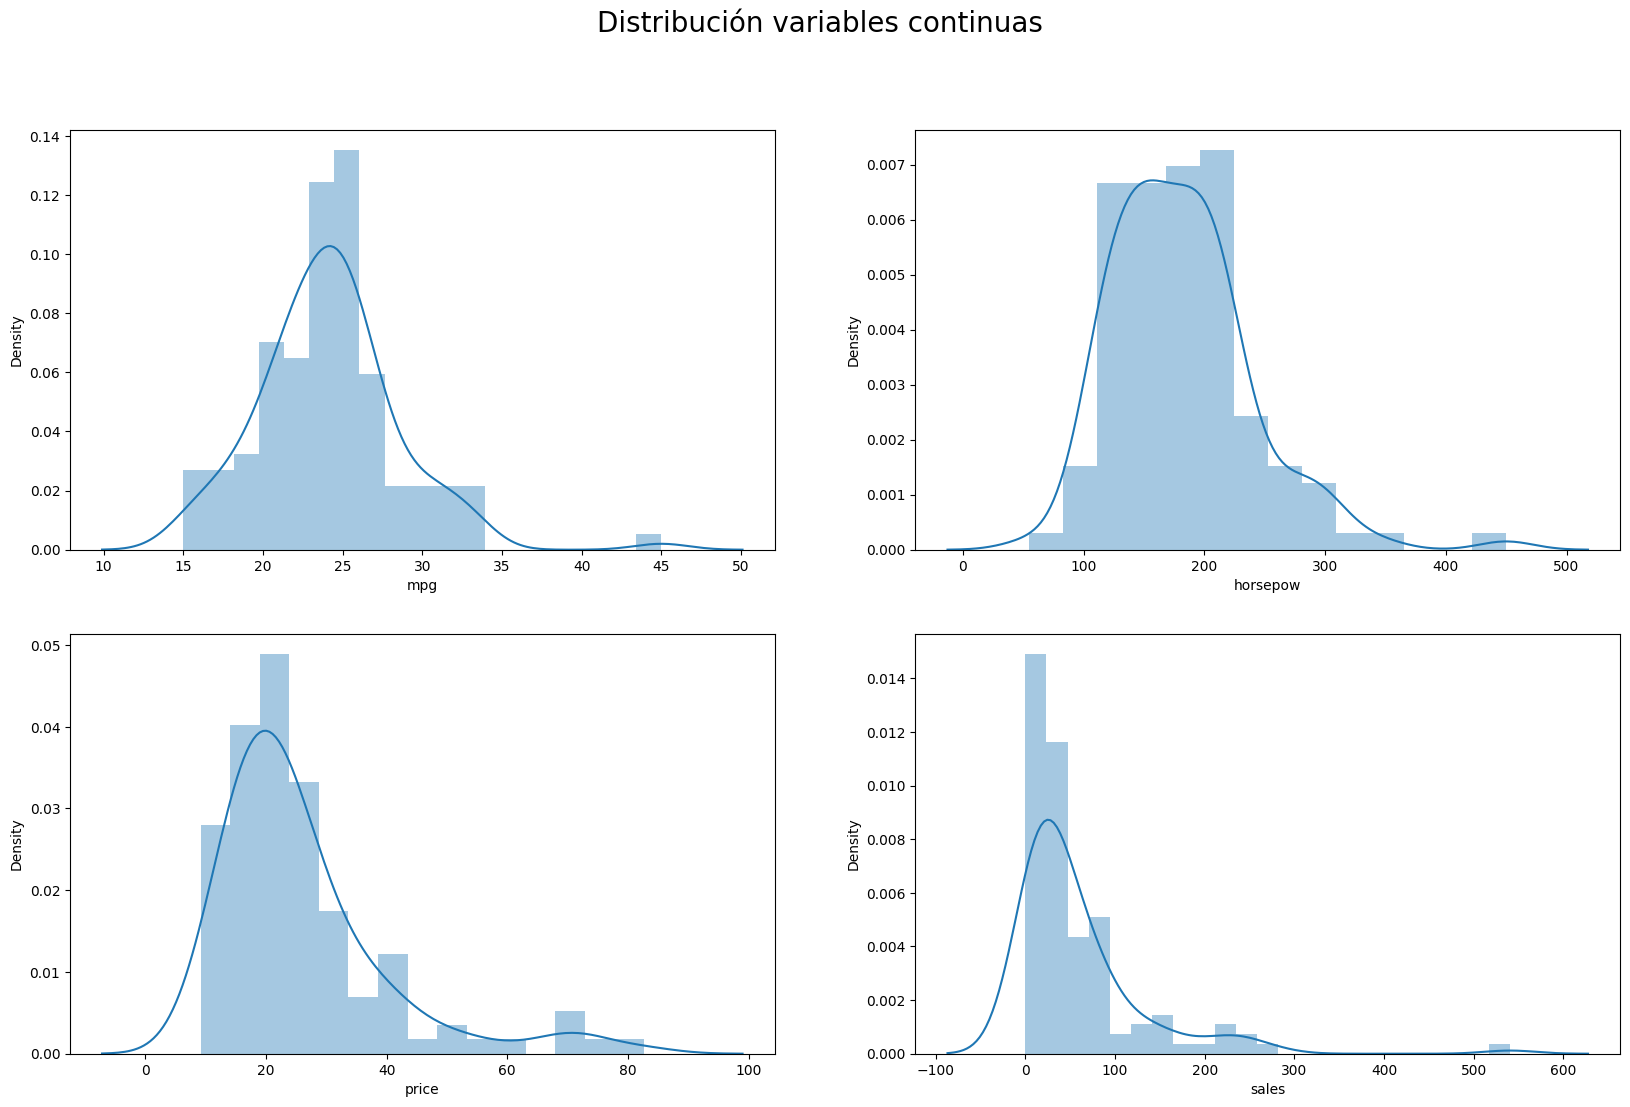

In [15]:
# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
import matplotlib.pyplot as plt


f, axes = plt.subplots(2,2, figsize=(20, 12))
f.suptitle("Distribución variables continuas", fontsize=20)

sns.distplot( df["mpg"], ax=axes[0,0])
sns.distplot( df["horsepow"], ax=axes[0,1])

sns.distplot( df["price"], ax=axes[1,0])
sns.distplot( df["sales"], ax=axes[1,1])


## Transformación y Limpieza

#### Eliminar atributos innecesarios

In [16]:
df=df.drop("partition",axis=1)
df.head()

,manufact,model,sales,resale,type,price,engine_s,horsepow,wheelbas,width,length,curb_wgt,fuel_cap,mpg,lnsales
0,Acura,Integra,16.919,16.360,0.000,21.500,1.800,140.000,101.200,67.300,172.400,2.639,13.200,28.000,2.828
1,Acura,TL,39.384,19.875,0.000,28.400,3.200,225.000,108.100,70.300,192.900,3.517,17.200,25.000,3.673
3,Acura,RL,8.588,29.725,0.000,42.000,3.500,210.000,114.600,71.400,196.600,3.850,18.000,22.000,2.150
4,Audi,A4,20.397,22.255,0.000,23.990,1.800,150.000,102.600,68.200,178.000,2.998,16.400,27.000,3.015
5,Audi,A6,18.780,23.555,0.000,33.950,2.800,200.000,108.700,76.100,192.000,3.561,18.500,22.000,2.933


#### Matriz de Correlación

# **Automatización**

In [17]:
columnas_numericas = ['sales', 'resale', 'price', 'engine_s', 'horsepow', 'wheelbas',
                      'width', 'length', 'curb_wgt', 'fuel_cap', 'mpg']

for col in columnas_numericas:
    df[col] = df[col].astype(float)

In [18]:
df = df.dropna(subset=columnas_numericas).reset_index(drop=True)

#### Pipeline

<Axes: >

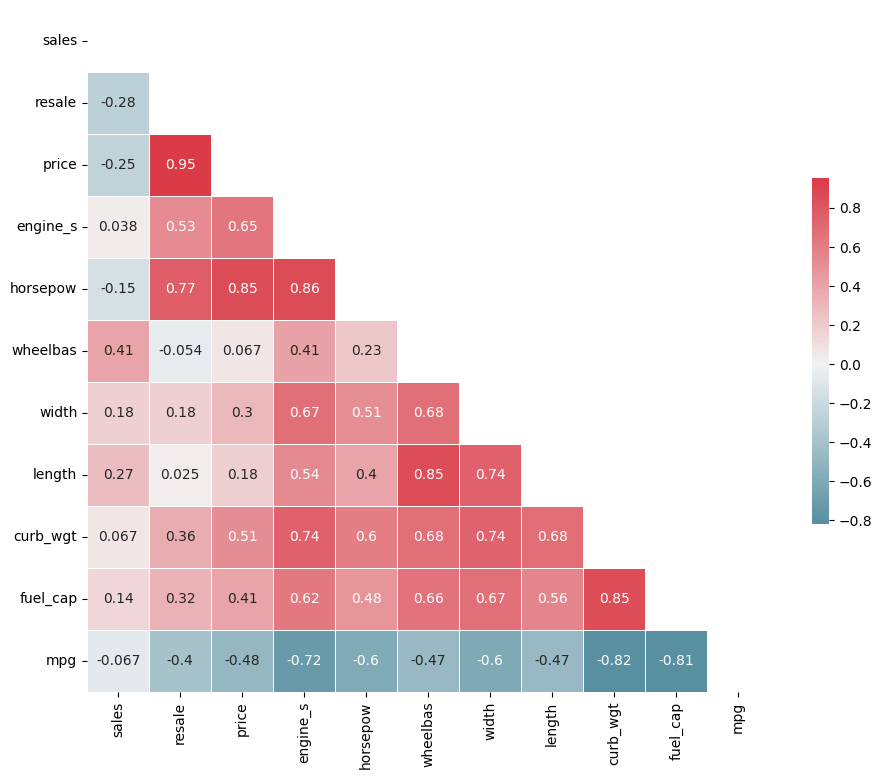

In [19]:
corr=df.corr(numeric_only=True)

mask = np.zeros_like(corr, dtype=bool);mask[np.triu_indices_from(mask)] = True

f, ax = plt.subplots(figsize=(11, 9))

cmap = sns.diverging_palette(220, 10, as_cmap=True)

sns.heatmap(corr, mask=mask, cmap=cmap, center=0,square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot = True)

In [20]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

In [21]:
pipeline_preprocesamiento = Pipeline([
    ('escalador', MinMaxScaler())
])

X = df[columnas_numericas]
X_escalado = pipeline_preprocesamiento.fit_transform(X)
X_escalado

array([[0.0311018 , 0.17951595, 0.16717781, ..., 0.2310559 , 0.13364055,
        0.43333333],
       [0.07266894, 0.2358551 , 0.26122811, ..., 0.50372671, 0.31797235,
        0.33333333],
       [0.0156869 , 0.39373297, 0.4466026 , ..., 0.60714286, 0.35483871,
        0.23333333],
       ...,
       [0.09435083, 0.18536624, 0.16308867, ..., 0.35652174, 0.28110599,
        0.4       ],
       [0.01750205, 0.18296201, 0.14659579, ..., 0.36770186, 0.15668203,
        0.36666667],
       [0.01015078, 0.1378426 , 0.1126559 , ..., 0.26925466, 0.19815668,
        0.36666667]])

Mejor número de clusters: 2
Mejor Silhouette Score: 0.22


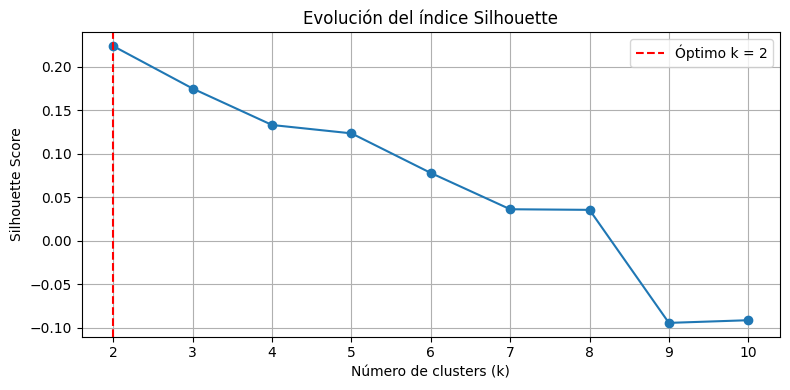

In [22]:
rango_clusters = range(2, 11)
valores_silhouette = []

mejor_score = -1
mejor_k = None
mejores_etiquetas = None

for k in rango_clusters:
    pipeline = Pipeline([
        ('escalador', MinMaxScaler()),
        ('cluster', AgglomerativeClustering(n_clusters=k,metric='euclidean',
                    linkage='complete'))
    ])

    # Ajustar y obtener etiquetas
    pipeline.fit(X)
    etiquetas = pipeline.named_steps['cluster'].labels_

    # Calcular silhouette solo si hay más de un cluster válido
    if len(set(etiquetas)) > 1:
        score = silhouette_score(X, etiquetas)
        valores_silhouette.append(score)

        if score > mejor_score:
            mejor_score = score
            mejor_k = k
            mejores_etiquetas = etiquetas
    else:
        valores_silhouette.append(-1)

# 3. Mostrar resultado óptimo
print(f"Mejor número de clusters: {mejor_k}")
print(f"Mejor Silhouette Score: {mejor_score:.2f}")

# 4. Graficar la evolución del Silhouette Score
plt.figure(figsize=(8, 4))
plt.plot(rango_clusters, valores_silhouette, marker='o', linestyle='-')
plt.axvline(x=mejor_k, color='red', linestyle='--', label=f"Óptimo k = {mejor_k}")
plt.title("Evolución del índice Silhouette")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
mejores_etiquetas

array([1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1])

### Asignación de grupos

In [23]:
df['cluster_'] = mejores_etiquetas

tamanos_clusters = df['cluster_'].value_counts().to_frame()
tamanos_clusters.columns = ['Tamaño_Cluster']

In [24]:
# Mostrar resultados
df.head()

,manufact,model,sales,resale,type,price,engine_s,horsepow,wheelbas,width,length,curb_wgt,fuel_cap,mpg,lnsales,cluster_
0,Acura,Integra,16.919,16.360,0.000,21.50,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,2.828,1
1,Acura,TL,39.384,19.875,0.000,28.40,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,3.673,1
2,Acura,RL,8.588,29.725,0.000,42.00,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,2.150,1
3,Audi,A4,20.397,22.255,0.000,23.99,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,3.015,1
4,Audi,A6,18.780,23.555,0.000,33.95,2.8,200.0,108.7,76.1,192.0,3.561,18.5,22.0,2.933,0


### Clustering jerárquico

Un dendograma es una representación gráfica de los resultados de un análisis de agrupamiento jerárquico (clustering). Muestra cómo se organizan las muestras en grupos o clústeres a diferentes niveles de similitud. En el dendograma, las muestras que están más cerca unas de otras están en ramas más cercanas, mientras que las muestras menos similares están separadas en ramas más lejanas.

Aquí tienes una breve guía sobre los conceptos clave y cómo interpretar un dendograma, junto con recursos para trabajar con él en Python, utilizando bibliotecas comunes como scipy y matplotlib:

**1. Conceptos Básicos del Dendograma**

Agrupamiento Jerárquico: Este es el proceso de construir una jerarquía de clústeres. Existen dos enfoques principales:

* Aglomerativo (de abajo hacia arriba): Comienza tratando cada muestra como su propio clúster y luego fusiona los clústeres más cercanos en cada paso.
* Divisivo (de arriba hacia abajo): Comienza con todas las muestras en un solo clúster y divide iterativamente en clústeres más pequeños.

**Distancia y Similitud:** La medida de distancia (como la distancia euclidiana o la distancia de Manhattan) se utiliza para determinar qué tan cerca están las muestras unas de otras.

**Métodos de Enlace:** Hay varias formas de calcular la distancia entre clústeres cuando se construye el dendograma:

* Enlace simple: Usa la distancia mínima entre puntos de dos clústeres.
* Enlace completo: Usa la distancia máxima.
* Enlace promedio: Usa la distancia promedio.
* Enlace de Ward: Minimiza la varianza dentro de cada clúster.

**2. Interpretación del Dendograma**

* Altura: En el eje vertical, la altura donde dos ramas se unen representa la distancia o disimilitud entre los clústeres. Cuanto más alta es la unión, menos similares son los clústeres.

* Corte del Dendograma: Un punto de corte horizontal en el dendograma divide el árbol en clústeres. Los clústeres por encima de la línea de corte permanecen agrupados, mientras que los por debajo están separados. El nivel de corte determina la cantidad de clústeres finales.

### **Dendrograma**


Los resultados del hierarchical clustering pueden representarse como un árbol en el que las ramas representan la jerarquía con la que se van sucediendo las uniones de clusters.

Supóngase que se dispone de 45 observaciones en un espacio de dos dimensiones, a los que se les aplica hierarchical clustering para intentar identificar grupos. El siguiente dendrograma representa los resultados obtenidos.
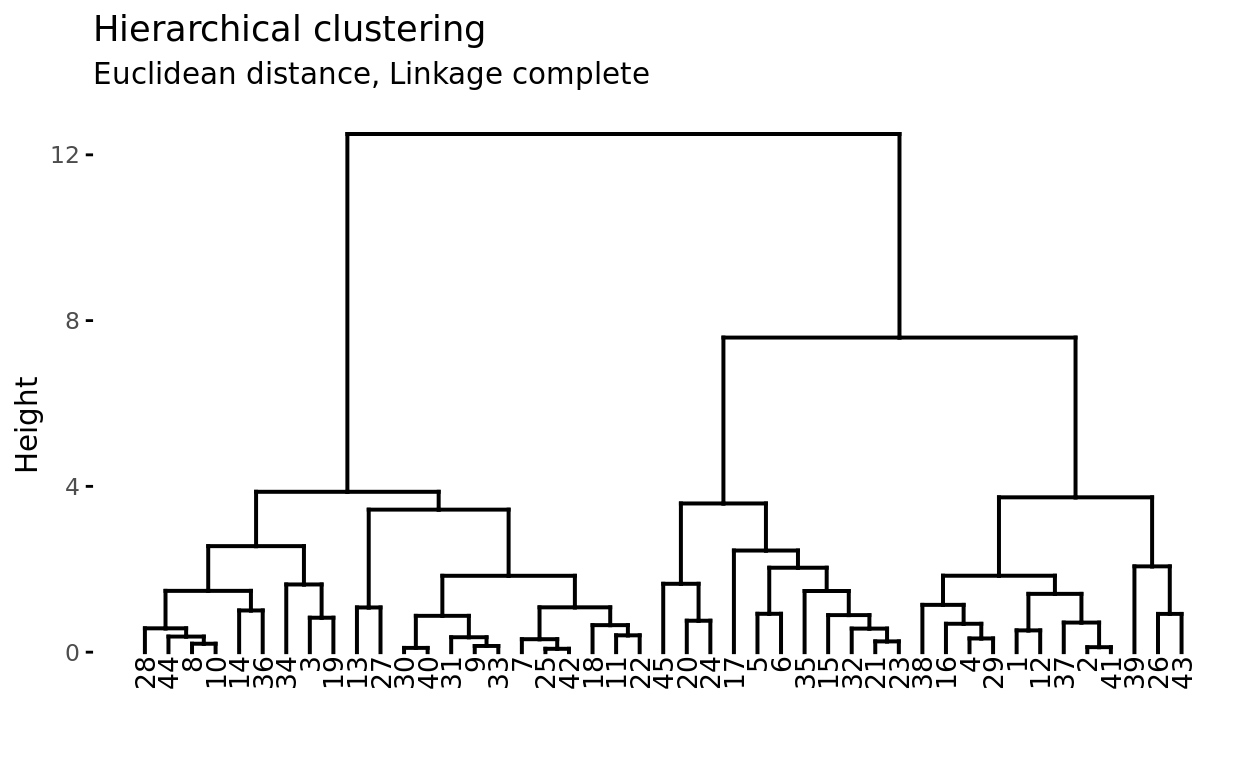


En la base del dendrograma, cada observación forma una terminación individual conocida como hoja o leaf del árbol. A medida que se asciende por la estructura, pares de hojas se fusionan formando las primeras ramas. Estas uniones se corresponden con los pares de observaciones más similares. También ocurre que las ramas se fusionan con otras ramas o con hojas. Cuanto más temprana (más próxima a la base del dendrograma) ocurre una fusión, mayor es la similitud.

Para cualquier par de observaciones, se puede identificar el punto del árbol en el que las ramas que contienen dichas observaciones se fusionan. La altura a la que esto ocurre (eje vertical) indica cómo de similares/diferentes son las dos observaciones. Los dendrogramas, por lo tanto, se deben interpretar únicamente en base al eje vertical y no por las posiciones que ocupan las observaciones en el eje horizontal, esto último es simplemente por estética y puede variar de un programa a otro.

Por ejemplo, la observación 8 es la más similar a la 10 ya que es la primera fusión que recibe la observación 10 (y viceversa). Podría resultar tentador decir que la observación 14, situada inmediatamente a la derecha de la 10, es la siguiente más similar, sin embargo, las observaciones 28 y 44 son más similares a la 10 a pesar de que se encuentran más alejadas en el eje horizontal. Del mismo modo, no es correcto decir que la observación 14 es más similar a la observación 10 de lo que lo es la 36 por el hecho de que está más próxima en el eje horizontal. Prestando atención a la altura en que las respectivas ramas se unen, la única conclusión válida es que la similitud entre los pares 10-14 y 10-36 es la misma.


### **Cortar el dendograma para generar los clusters**


Además de representar en un dendrograma la similitud entre observaciones, se tiene que identificar el número de clusters creados y qué observaciones forman parte de cada uno. Si se realiza un corte horizontal a una determinada altura del dendrograma, el número de ramas que sobrepasan (en sentido ascendente) dicho corte se corresponde con el número de clusters. La siguiente imagen muestra dos veces el mismo dendrograma. Si se realiza el corte a la altura de 5, se obtienen dos clusters, mientras que si se hace a la de 3.5 se obtienen 4. La altura de corte tiene por lo tanto la misma función que el valor K en K-means-clustering: controla el número de clusters obtenidos.

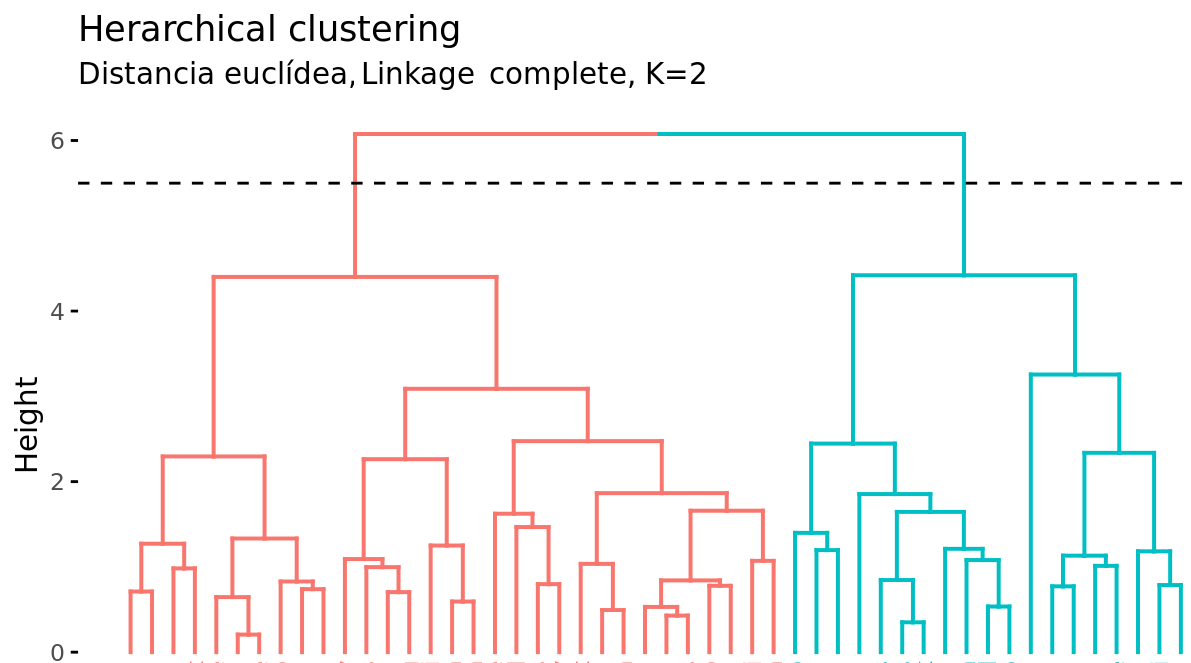

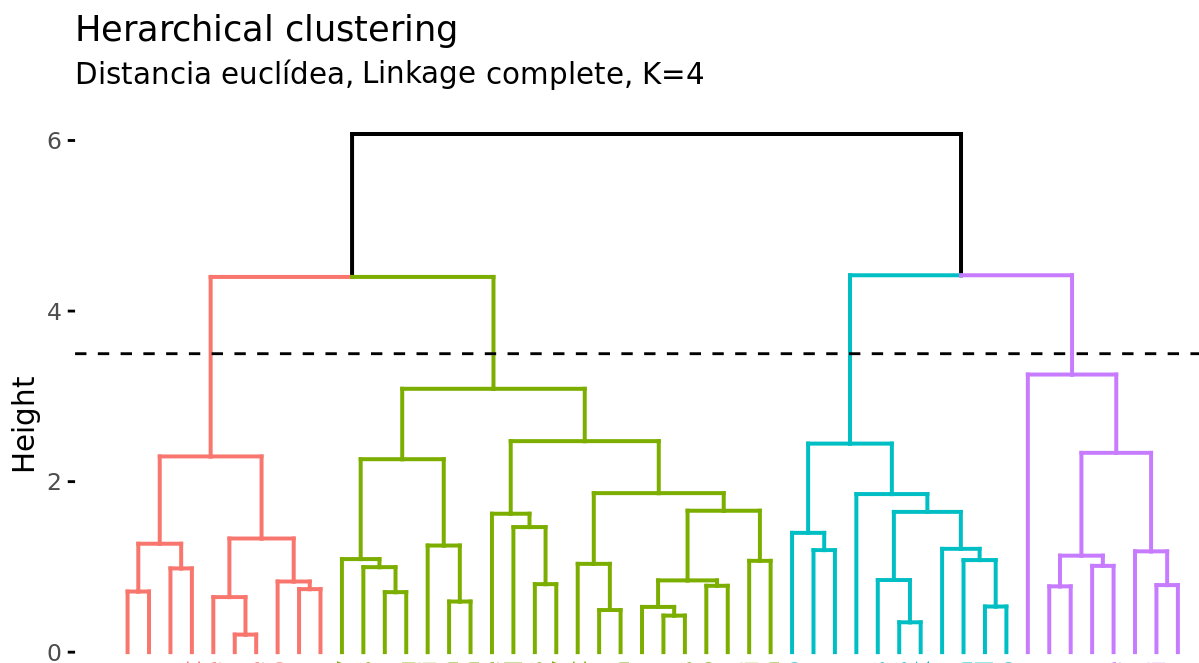

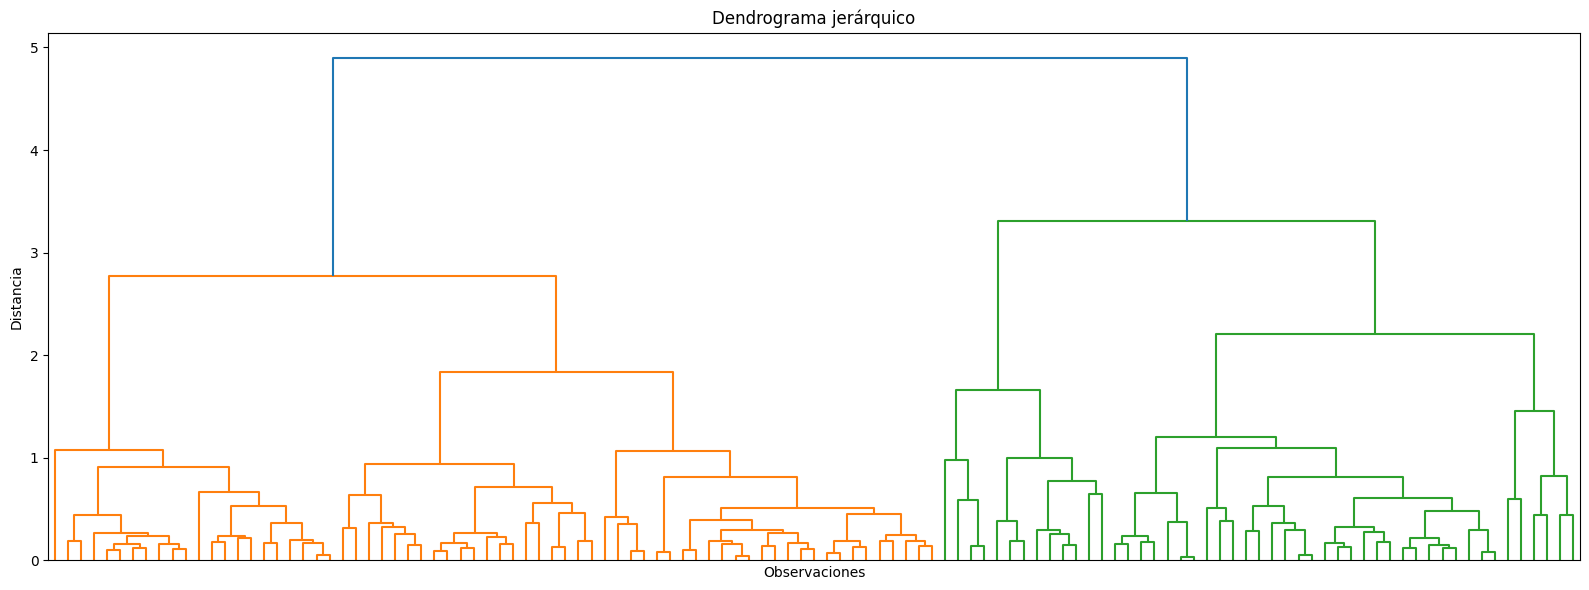

In [25]:
from scipy.cluster.hierarchy import linkage, dendrogram
# Calcular la matriz de linkage
Z = linkage(X_escalado, method='ward')

# 3. Graficar dendrograma
plt.figure(figsize=(16, 6))
dendrogram(Z, truncate_mode=None, no_labels=True)
plt.title("Dendrograma jerárquico")
plt.xlabel("Observaciones")
plt.ylabel("Distancia")
plt.tight_layout()
plt.show()

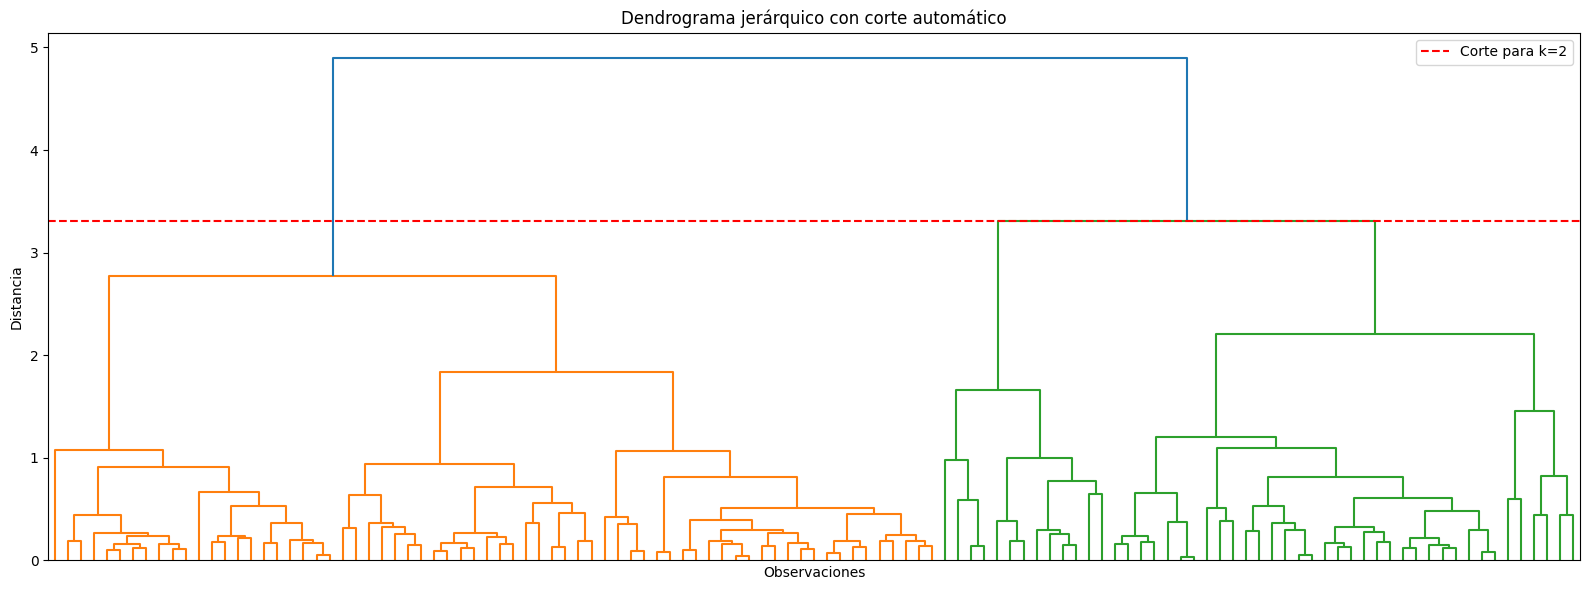

In [26]:
from scipy.cluster.hierarchy import fcluster

# Cortar el dendrograma con el mejor número de clusters encontrado
etiquetas = fcluster(Z, mejor_k, criterion='maxclust')

# Estimar altura de corte (aproximadamente)
altura_corte = sorted(Z[:, 2])[-mejor_k]

# Volver a graficar con línea roja del corte
plt.figure(figsize=(16, 6))
dendrogram(Z, truncate_mode=None, no_labels=True)
plt.axhline(y=altura_corte, color='red', linestyle='--', label=f'Corte para k={mejor_k}')
plt.title("Dendrograma jerárquico con corte automático")
plt.xlabel("Observaciones")
plt.ylabel("Distancia")
plt.legend()
plt.tight_layout()
plt.show()


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117 entries, 0 to 116
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   manufact  117 non-null    object 
 1   model     117 non-null    object 
 2   sales     117 non-null    float64
 3   resale    117 non-null    float64
 4   type      117 non-null    object 
 5   price     117 non-null    float64
 6   engine_s  117 non-null    float64
 7   horsepow  117 non-null    float64
 8   wheelbas  117 non-null    float64
 9   width     117 non-null    float64
 10  length    117 non-null    float64
 11  curb_wgt  117 non-null    float64
 12  fuel_cap  117 non-null    float64
 13  mpg       117 non-null    float64
 14  lnsales   117 non-null    object 
 15  cluster_  117 non-null    int64  
dtypes: float64(11), int64(1), object(4)
memory usage: 14.8+ KB


### Visualización#1: Horsepower y Mpg

Text(0, 0.5, 'mpg')

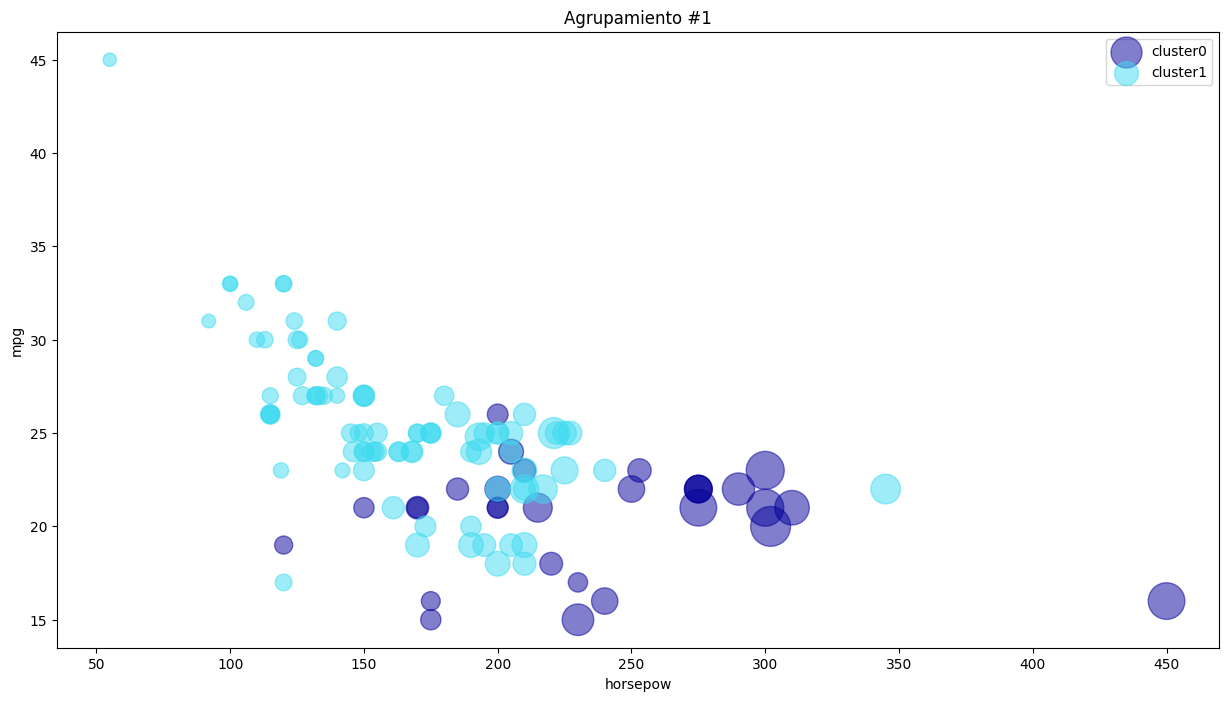

In [28]:
import matplotlib.cm as cm

n_clusters = df['cluster_'].nunique()


colors=['#04009A','#3EDBF0','#9EDE73','#FA1E0E','purple','#FFE227']

cluster_labels = list(range(0, n_clusters))


plt.figure(figsize=(15,8))

for color, label in zip(colors, cluster_labels):
    subset = df[df.cluster_ == label]
#    for i in subset.index:
#        plt.text(subset.horsepow[i], subset.mpg[i],str(subset['model'][i]), rotation=25)
    plt.scatter(subset.horsepow, subset.mpg, s= subset.price*10, c=color, label='cluster'+str(label),alpha=0.5)

plt.legend()
plt.title('Agrupamiento #1')
plt.xlabel('horsepow')
plt.ylabel('mpg')

In [29]:
df.head()

,manufact,model,sales,resale,type,price,engine_s,horsepow,wheelbas,width,length,curb_wgt,fuel_cap,mpg,lnsales,cluster_
0,Acura,Integra,16.919,16.360,0.000,21.50,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,2.828,1
1,Acura,TL,39.384,19.875,0.000,28.40,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,3.673,1
2,Acura,RL,8.588,29.725,0.000,42.00,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,2.150,1
3,Audi,A4,20.397,22.255,0.000,23.99,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,3.015,1
4,Audi,A6,18.780,23.555,0.000,33.95,2.8,200.0,108.7,76.1,192.0,3.561,18.5,22.0,2.933,0


### Visualizacion #2: Width y Length

Text(0, 0.5, 'Length')

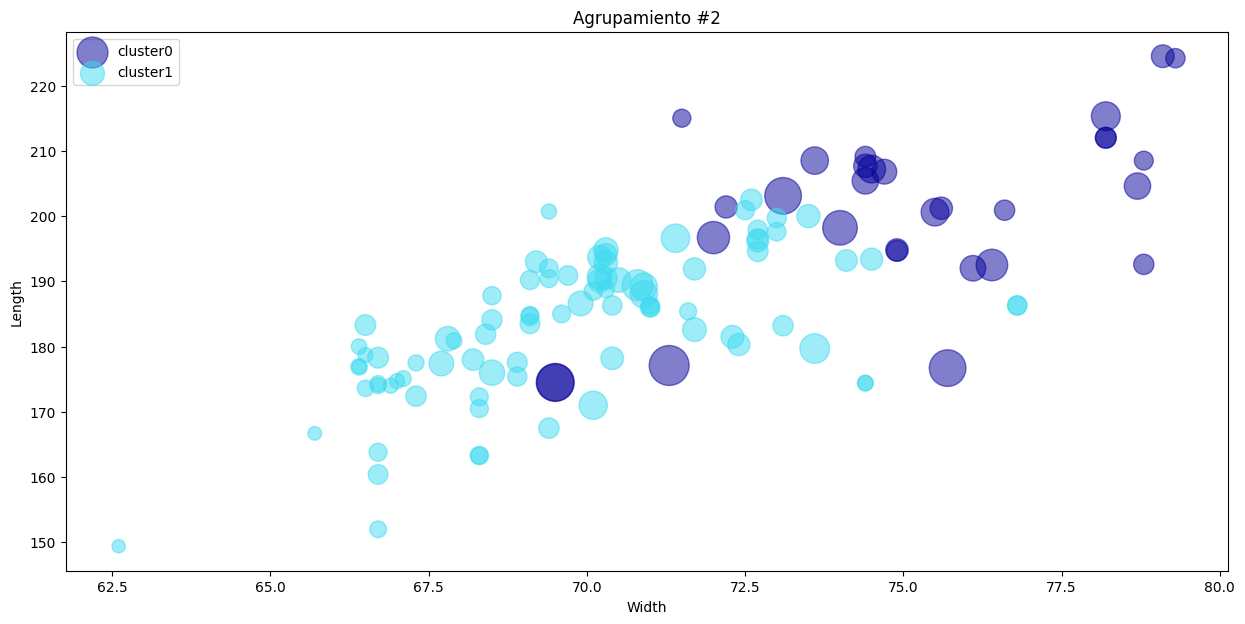

In [30]:
plt.figure(figsize=(15, 7))

for color, label in zip(colors, cluster_labels):
    subset = df[df.cluster_ == label]
    plt.scatter(subset.width, subset.length, s= subset.price*10, c=color, label='cluster'+str(label),alpha=0.5)

plt.legend()
plt.title('Agrupamiento #2')
plt.xlabel('Width')
plt.ylabel('Length')

### Visualización #3: Engine Size y Horse Power

Text(0, 0.5, 'Horse Power')

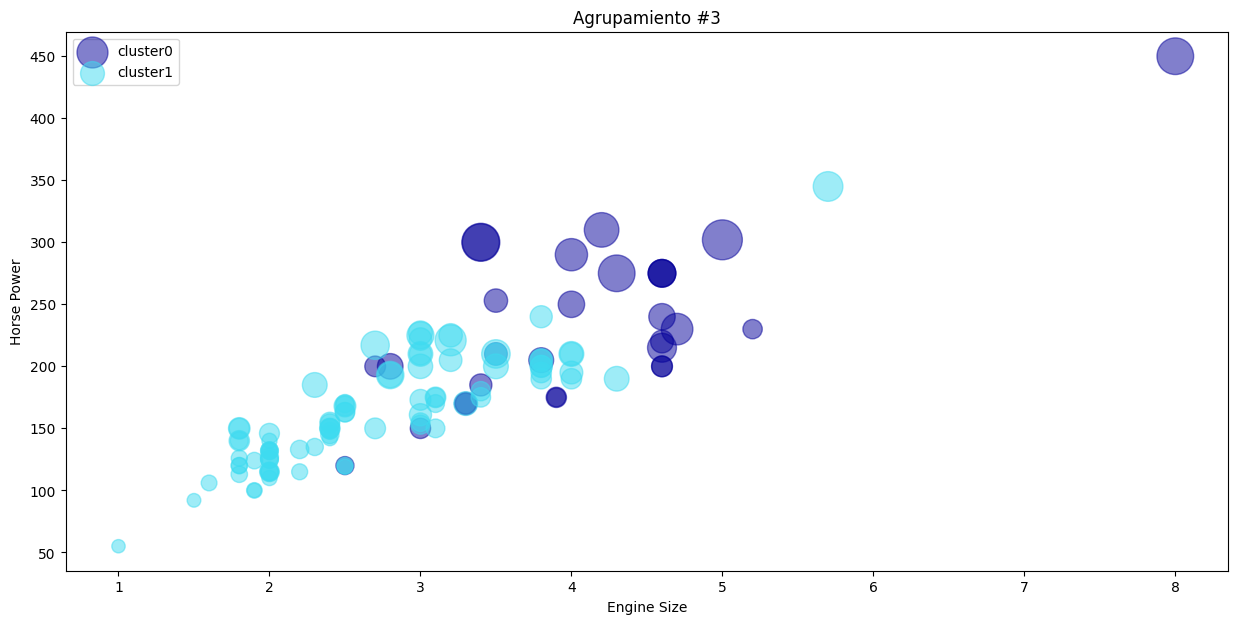

In [31]:
plt.figure(figsize=(15, 7))

for color, label in zip(colors, cluster_labels):
    subset = df[df.cluster_ == label]
    plt.scatter(subset.engine_s, subset.horsepow, s= subset.price*10, c=color, label='cluster'+str(label),alpha=0.5)

plt.legend()
plt.title('Agrupamiento #3')
plt.xlabel('Engine Size')
plt.ylabel('Horse Power')

#### Explorar características de cada cluster

In [32]:
df.groupby(['cluster_','type'])['cluster_'].count()

cluster_  type 
0         0.000    18
          1.000    12
1         0.000    70
          1.000    17
Name: cluster_, dtype: int64

In [33]:
agg_cars = df.groupby(['cluster_', 'type'])[['horsepow', 'engine_s', 'mpg', 'price']].mean()
agg_cars

horsepow  engine_s        mpg      price
cluster_ type                                             
0        0.000  265.277778  4.261111  21.666667  46.862167
         1.000  189.583333  3.825000  18.666667  26.066000
1        0.000  161.614286  2.598571  26.454286  21.372914
         1.000  167.470588  3.070588  20.941176  22.706765

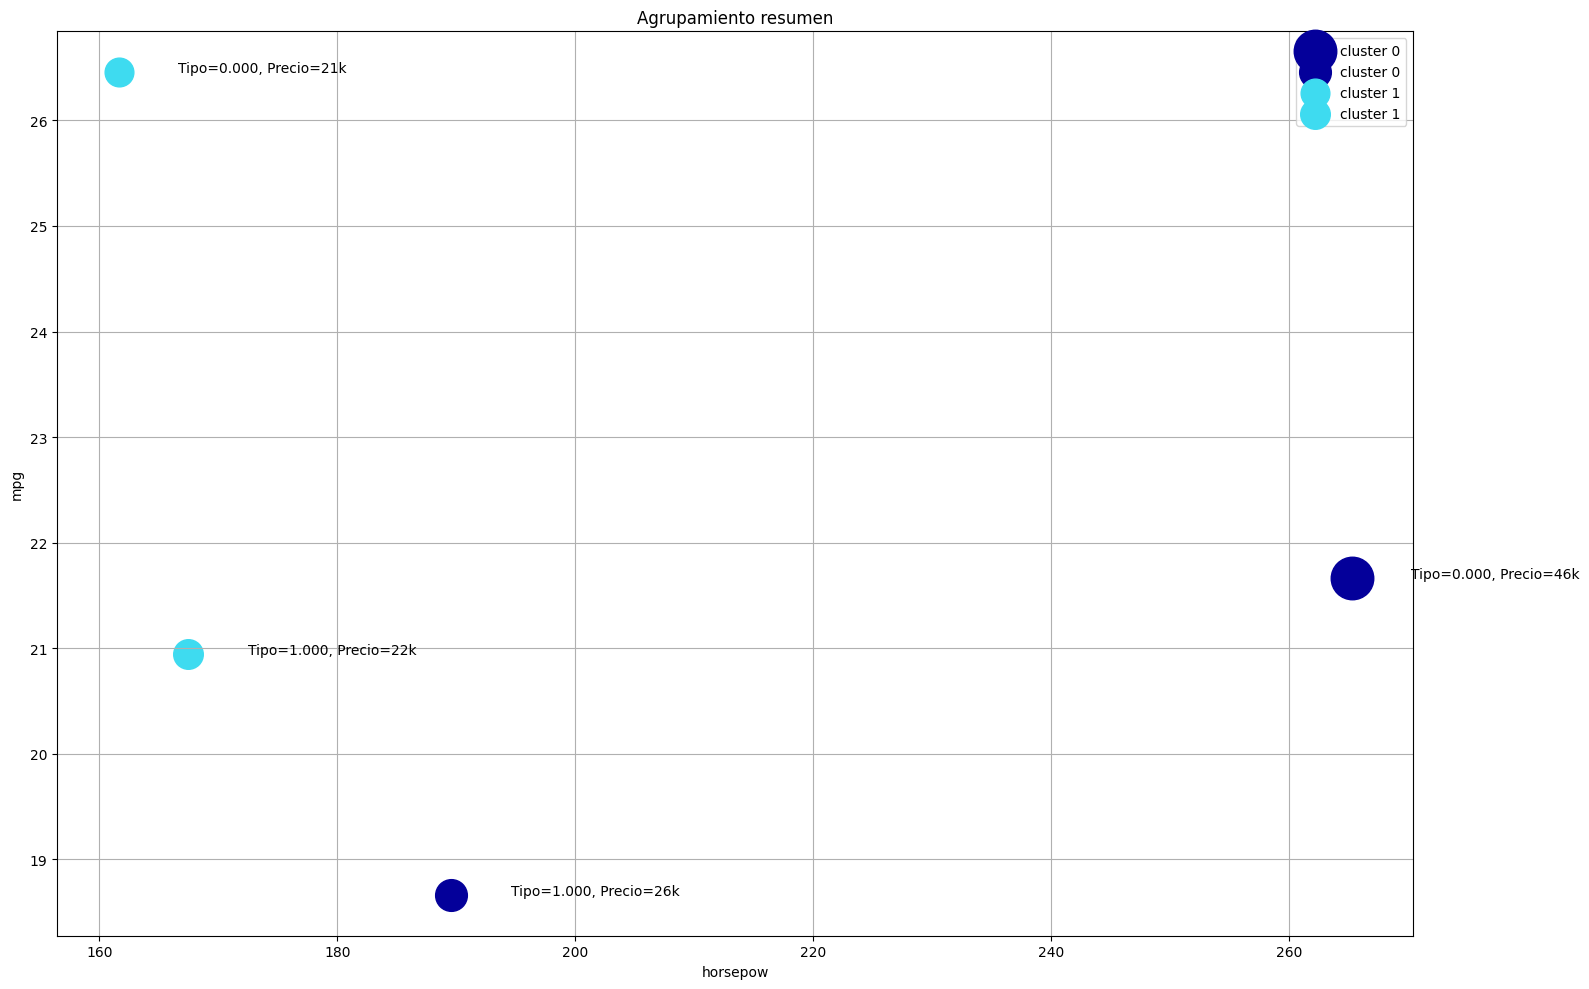

In [34]:
agg_cars_reset = agg_cars.reset_index()

plt.figure(figsize=(16,10))
for color, label in zip(colors, cluster_labels):
    # Filtrar por cluster
    subset = agg_cars_reset[agg_cars_reset['cluster_'] == label]

    for _, fila in subset.iterrows():
        x = fila['horsepow']
        y = fila['mpg']
        precio = fila['price']
        tipo = fila['type']
        plt.text(x + 5, y, f'Tipo={tipo}, Precio={int(precio)}k')
        plt.scatter(x, y, s=precio * 20, c=[color], label=f'cluster {label}')

plt.legend()
plt.title('Agrupamiento resumen')
plt.xlabel('horsepow')
plt.ylabel('mpg')
plt.grid(True)
plt.tight_layout()
plt.show()

### Consultar vehículos de un cluster específico

### Cluster 1


In [35]:
df[df.cluster_==0]

,manufact,model,sales,resale,type,price,engine_s,horsepow,wheelbas,width,length,curb_wgt,fuel_cap,mpg,lnsales,cluster_
4,Audi,A6,18.780,23.555,0.000,33.950,2.8,200.0,108.7,76.1,192.0,3.561,18.5,22.0,2.933,0
5,Audi,A8,1.380,39.000,0.000,62.000,4.2,310.0,113.0,74.0,198.2,3.902,23.7,21.0,0.322,0
10,Buick,Park Avenue,27.851,20.190,0.000,31.965,3.8,205.0,113.8,74.7,206.8,3.778,18.5,24.0,3.327,0
12,Cadillac,DeVille,63.729,22.525,0.000,39.895,4.6,275.0,115.3,74.5,207.2,3.978,18.5,22.0,4.155,0
13,Cadillac,Eldorado,6.536,25.725,0.000,39.665,4.6,275.0,108.0,75.5,200.6,3.843,19.0,22.0,1.877,0
25,Chrysler,Concorde,31.148,13.725,0.000,22.245,2.7,200.0,113.0,74.4,209.1,3.452,17.0,26.0,3.439,0
27,Chrysler,LHS,13.462,17.325,0.000,28.340,3.5,253.0,113.0,74.4,207.7,3.564,17.0,23.0,2.600,0
31,Dodge,Viper,0.916,58.470,0.000,69.725,8.0,450.0,96.2,75.7,176.7,3.375,19.0,16.0,-0.088,0
32,Dodge,Ram Pickup,227.061,15.060,1.000,19.460,5.2,230.0,138.7,79.3,224.2,4.470,26.0,17.0,5.425,0
33,Dodge,Ram Wagon,16.767,15.510,1.000,21.315,3.9,175.0,109.6,78.8,192.6,4.245,32.0,15.0,2.819,0


### Cluster 2

In [36]:
df[df.cluster_==1]

,manufact,model,sales,resale,type,price,engine_s,horsepow,wheelbas,width,length,curb_wgt,fuel_cap,mpg,lnsales,cluster_
0,Acura,Integra,16.919,16.360,0.000,21.50,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,2.828,1
1,Acura,TL,39.384,19.875,0.000,28.40,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,3.673,1
2,Acura,RL,8.588,29.725,0.000,42.00,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,2.150,1
3,Audi,A4,20.397,22.255,0.000,23.99,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,3.015,1
6,BMW,328i,9.231,28.675,0.000,33.40,2.8,193.0,107.3,68.5,176.0,3.197,16.6,24.0,2.223,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112,Volkswagen,Golf,9.761,11.425,0.000,14.90,2.0,115.0,98.9,68.3,163.3,2.767,14.5,26.0,2.278,1
113,Volkswagen,Jetta,83.721,13.240,0.000,16.70,2.0,115.0,98.9,68.3,172.3,2.853,14.5,26.0,4.427,1
114,Volkswagen,Passat,51.102,16.725,0.000,21.20,1.8,150.0,106.4,68.5,184.1,3.043,16.4,27.0,3.934,1
115,Volkswagen,Cabrio,9.569,16.575,0.000,19.99,2.0,115.0,97.4,66.7,160.4,3.079,13.7,26.0,2.259,1
